<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/ESR/ESR_signal_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESR Oscillator: Signal Chain Analysis

Evgeny Kolonsky, 2026

v0.1.1 1kHz uncertainty corrected

v0.1.2 table formatting

v0.1.3 Bloch equations not relevant here - removed. R=1MOhm instead of 280kOhm


This notebook explains the signal chain in the ESR oscillator circuit,
from the complex magnetic susceptibility $\chi = \chi' - i \chi''$ of the sample to the output voltage signal.

The output signal interpretaion depends on modulation frequency. It is shown that in all cases, it is a function of absorptive component of the  susceptibility $\chi''$. At 1kHz modulation frequency the output signal is proportional to $\chi''$ value minus a DC constant. At 50 Hz modulation frequency the output signal is a mix of $\chi''$ and it's derivatives. At low frequencies it would be first derivative of $\chi''(B)$.

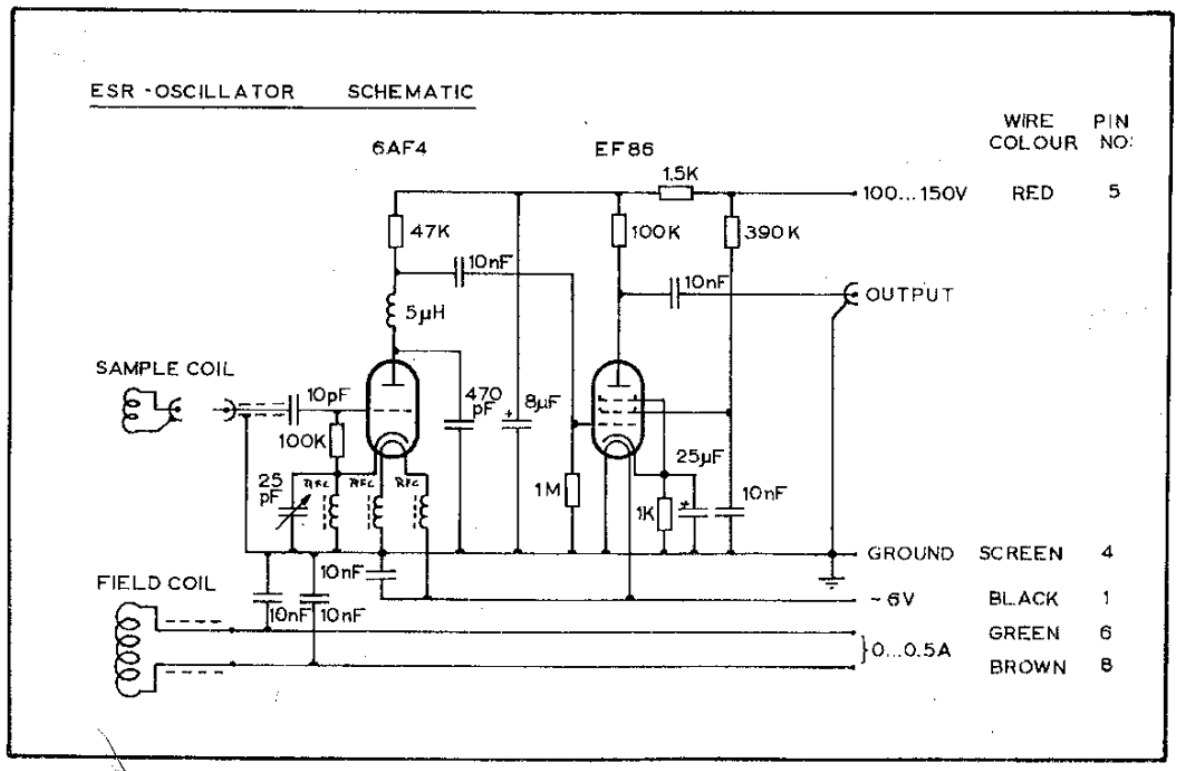

## 1. Complex Magnetic Susceptibility

The response of a magnetic material to an oscillating field $H$ is described by the **complex susceptibility**:

$$\chi = \chi' - i\chi''$$

The field and magnetization are related by:

$$M = \chi H$$

The two components have distinct physical meanings:

- $\chi'$ — **dispersive** (real) part: describes the reactive response. It is in phase with the driving field and shifts the resonance frequency of the LC circuit.
- $\chi''$ — **absorptive** (imaginary) part: describes energy dissipation. It is 90° out of phase with the driving field and increases the losses in the LC circuit.


From the Bloch equations we expect the lorentzian shape of dependence $\chi''(B)$.

## 2. Signal Chain: From Sample to Output

### Step 1 — Triode oscillator (6AF4)

The sample coil is part of a resonant LC circuit connected to the triode grid.
The triode sustains oscillations at $\nu_{\mathrm{RF}} \approx 100\,\mathrm{MHz}$.

The sample sits inside the coil. When ESR occurs, $\chi''$ increases.
This increases the **effective resistance** of the coil:
$$R_{\mathrm{eff}} = \omega_{\mathrm{RF}} L_0 \chi''$$

The effective inductance of the coil also increases:
$$
L_{\mathrm{eff}}=L_0​(1+\chi').
$$

Higher losses reduce the oscillation amplitude $A_{\mathrm{RF}}$.
In the linear regime:

$$A_{\mathrm{RF}}(t) \propto 1 - \alpha \cdot \chi''(B(t))$$

**Why $\chi''$ and not $\chi'$?**  
The triode feedback phase is tuned so that the output is sensitive to changes in $R_{\mathrm{eff}}$ (loss), not $L_{\mathrm{eff}}$ (reactance).  
A change in $\chi'$ shifts the oscillation frequency slightly but does not affect the amplitude.  
A change in $\chi''$ changes the losses and therefore the amplitude.
The output is therefore proportional to $\chi''$, not $\chi'$.

---

### Step 2 — Pentode rectifier (EF86)

The RF signal from the triode anode is coupled to the pentode grid through a $10\,\mathrm{nF}$ capacitor.
This capacitor is transparent at $100\,\mathrm{MHz}$ but blocks low-frequency components.

The pentode rectifies the RF signal (acts as an envelope detector).
It outputs a slowly varying DC voltage proportional to the RF amplitude.
The pentode also **inverts** the signal. Therefore:

$$S(t) \equiv V_{\mathrm{anode}}(t) \propto \chi''(B(t))$$

This is a slow signal — it varies on the timescale of the field modulation (ms), not the RF period (ns).

---

### Step 3 — RC output filter

The pentode anode is connected to the output through a coupling capacitor $C = 10\,\mathrm{nF}$.
The load resistance is $R =  R_{\mathrm{scope}} = 1\,\mathrm{M}\Omega $.

The RC time constant is:
$$\tau = RC = 1 \times 10^6 \times 10 \times 10^{-9} = 10\,\mathrm{ms}$$

**Purpose of the RC filter:** The DC component of $S(t)$ (large background level from the oscillator, unrelated to ESR) is much larger than the small ESR signal $\delta\chi''$. The capacitor blocks this DC background, leaving only the time-varying ESR signal.

## 3. Output Signal as a Fourier Series

The magnetic field is modulated sinusoidally:

$$B(t) = B_{\mathrm{DC}} + B_m \sin(\omega_m t)$$

The signal $S(t) = \chi''(B(t))$ is periodic with period $T = 2\pi/\omega_m$.
It can be expanded in a Fourier series:

$$S(t) = c_0 + \sum_{n=1}^{\infty} c_n(B_{\mathrm{DC}}, B_m) \sin(n\omega_m t + \phi_n)$$

The RC high-pass filter has the transfer function:

$$H(\omega) = \frac{i\omega\tau}{1 + i\omega\tau}, \qquad |H(\omega)| = \frac{\omega\tau}{\sqrt{1 + (\omega\tau)^2}}$$

The DC component ($n=0$) is blocked: $H(0) = 0$.  
Each harmonic $n$ is transmitted with its own amplitude and phase.
The output is:

$$\boxed{V_{\mathrm{out}}(t) = \sum_{n=1}^{\infty} H(n\omega_m) \cdot c_n \cdot \sin(n\omega_m t + \phi_n + \angle H(n\omega_m))}$$

## 4. Limiting Cases

### Case A: High frequency — $\omega_m \tau \gg 1$

When $\omega_m \tau \gg 1$:

$$|H(n\omega_m)| = \frac{n\omega_m\tau}{\sqrt{1 + (n\omega_m\tau)^2}} \approx 1$$

All harmonics are transmitted with unit gain. The filter passes the full signal.
Only the DC component is blocked:

$$V_{\mathrm{out}}(t) \approx S(t) - \langle S \rangle = \chi''(B(t)) - \langle \chi'' \rangle$$

The output is proportional to $\chi''$ itself, with the mean value subtracted.

---

### Case B: Low frequency — $\omega_m \tau \ll 1$

When $\omega_m \tau \ll 1$:

$$|H(n\omega_m)| \approx n\omega_m\tau \ll 1$$

Each harmonic $n$ is multiplied by $n\omega_m\tau$. This is exactly what a time derivative does:

$$\frac{d}{dt}\left[c_n \sin(n\omega_m t)\right] = n\omega_m c_n \cos(n\omega_m t)$$

Therefore the filter differentiates the signal:

$$V_{\mathrm{out}}(t) \approx \tau \cdot \frac{dS}{dt} = \tau \cdot \frac{d\chi''}{dB} \cdot \frac{dB}{dt}$$

With $B(t) = B_{\mathrm{DC}} + B_m\sin(\omega_m t)$:

$$V_{\mathrm{out}}(t) \approx \tau \cdot B_m\omega_m\cos(\omega_m t) \cdot \frac{d\chi''}{dB}\bigg|_{B(t)}$$

## 5. The 50 Hz Case is Intermediate

For $f_m = 50\,\mathrm{Hz}$ and $\tau = 10\,\mathrm{ms}$:

$$\omega_m\tau = 2\pi \times 50 \times 10\times10^{-3} \approx 3$$

This is of order unity — neither $\gg 1$ nor $\ll 1$.

Different harmonics are transmitted with different weights.
The output is **neither** $\chi''$ **nor** $d\chi''/dt$ — it is a mixture of both.

For $f_m = 1\,\mathrm{kHz}$: $\omega_m\tau = 60 \gg 1$ → output $\approx \chi''(B(t)) - \langle\chi''\rangle$.

The table below summarises both experimental regimes:

| Regime | $f_m$ | $\omega_m\tau$ | $V_{\mathrm{out}}$ | Use |
|--------|--------|----------------|---------------------|-----|
| Part I | 50 Hz | 3 | mixture of $\chi''$ and $d\chi''/dt$ | find $B_{\mathrm{res}}$ |
| Part II | 1 kHz | 60 | $\approx \chi''(B(t)) - \langle\chi''\rangle$ | measure lineshape |

## 6. Extracting $B_{\mathrm{res}}$ and DC Offset from Part I Data

In Part I the field sweeps through both $+B_{\mathrm{res}}$ and $-B_{\mathrm{res}}$ each period.
The ESR signal appears four times per cycle.

Ch1 (voltage across the sensing resistor) is proportional to the total field:

$$V_1(t) = k \cdot B(t) = k \cdot \left(B_{\mathrm{DC}} + B_m\sin(\omega_m t)\right)$$

At each resonance event, $B(t^*) = \pm B_{\mathrm{res}}$, so Ch1 reads:

$$V_1(t^*) = k \cdot (\pm B_{\mathrm{res}})$$

If there is a DC offset $B_{\mathrm{DC}} \neq 0$ in the field (e.g. Earth's field, residual DC current), then the observed resonance values are:

- Positive half-cycle: Ch1 $= +B_{\mathrm{res}}$ (the total field, including offset, equals $+B_{\mathrm{res}}$)
- Negative half-cycle: Ch1 $= -B_{\mathrm{res}}$ (the total field equals $-B_{\mathrm{res}}$)

If $|V_+| \neq |V_-|$, a static external field $B_{\mathrm{DC}}$ is present.
From the four measured Ch1 values at resonance:

$$B_{\mathrm{res}} \propto \frac{|V_+| + |V_-|}{2}$$

$$B_{\mathrm{DC}} \propto \frac{|V_+| - |V_-|}{2}$$

where $|V_+|$ and $|V_-|$ are the mean absolute Ch1 values at positive and negative resonances.

The resonance condition then gives the gyromagnetic ratio:

$$h\nu_{\mathrm{RF}} = g\mu_B B_{\mathrm{res}} = \hbar\gamma B_{\mathrm{res}}$$

## 7. Summary

| Stage | Signal | Physical quantity &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|-------|--------|-------------------|
| Sample coil | increased losses | $\chi''(B)$ |
| Triode oscillator | reduced RF amplitude | $A_{\mathrm{RF}} \propto 1 - \alpha\chi''$ |
| Pentode anode | slow DC voltage | $S(t) \propto \chi''(B(t))$ |
| After RC filter (1 kHz) | AC signal, $\omega_m\tau \gg 1$ | $\chi''(B(t)) - \langle\chi''\rangle$ |
| After RC filter (50 Hz) | AC signal, $\omega_m\tau \sim 1$ | mixture of $\chi''$ and $d\chi''/dt$ |

**Key conclusions:**

1. The physical signal throughout the chain is $\chi''(B)$ — the absorptive susceptibility.
2. The RC filter removes the DC background. Its effect on the signal shape depends on $\omega_m\tau$.
3. At 50 Hz the output is an intermediate case: a narrow pulse with exponential tail.
4. From the 50 Hz data, $B_{\mathrm{res}}$ and $B_{\mathrm{DC}}$ are extracted from the Ch1 values at the resonance peaks.
5. At 1 kHz the output faithfully represents $\chi''(B(t))$, from which the lineshape and $T_2$ can be extracted.

In [ ]:
!pip install uncertainties

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.3 MB/s eta 0:00:00


# Resonanse  measurements

Resonanse is measured at 50 Hz, suggesting that small DC offset in modulations is not zero.

Then resonanse is found at 1kHz experiment, when the Ch2-Ch1 XY representation shows vertex of parabola

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties.umath import *

# 50 Hz experiment

DC offset = -14+/-3 mV
V_res = 445+/-3 mV


Text(23, 215.43466448790005, '445 ± 3 mV')

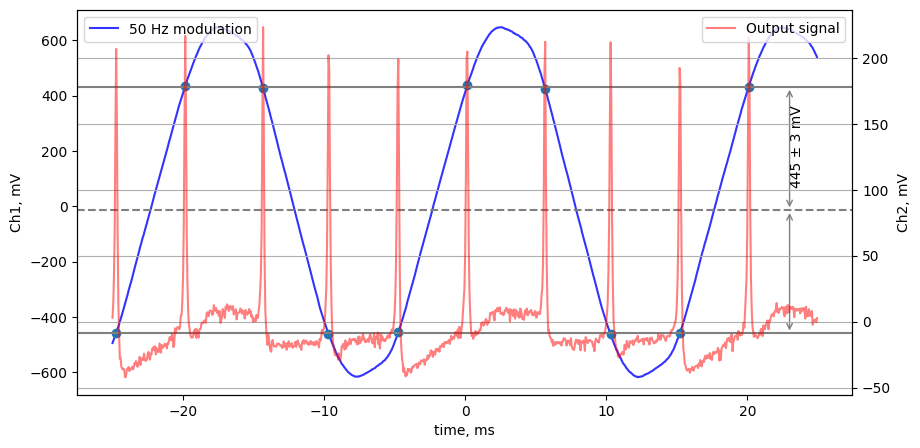

In [ ]:
filename = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/ESR/V_res/set2_50Hz.csv'

t, ch1, ch2 = np.genfromtxt(filename, skip_header=46, delimiter=',',
                     usecols=[1,2,3], unpack=True)
ch1 *=1e3 # mV
ch2 *=1e3 # mV
t *=1e3   # ms

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.plot(t, ch1,'-', color='blue', alpha=0.8, label='50 Hz modulation')
ax2.plot(t, ch2, '-', color='red', alpha=0.5, label='Output signal')
plt.grid()
peaks, locs = find_peaks(ch2, height=100, distance=50, prominence=100)
ax1.plot(t[peaks], ch1[peaks], 'o')

v = ch1[peaks]
v_plus = v[v>0]
vplus_mean = np.mean(v_plus)
vplus_std = np.std(v_plus)
vplus = ufloat(vplus_mean, vplus_std)

v_minus = v[v<0]
vminus_mean = np.mean(v_minus)
vminus_std = np.std(v_minus)
vminus = ufloat(vminus_mean, vminus_std)

ax1.set_ylabel('Ch1, mV')
ax2.set_ylabel('Ch2, mV')
ax1.set_xlabel('time, ms')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
v_dc = (vplus + vminus) / 2
v_res = (vplus - vminus) / 2
print(f'DC offset = {v_dc:.0f} mV')
print(f'V_res = {v_res:.0f} mV')

ax1.axhline(vplus_mean, color='gray')
ax1.axhline(vminus_mean, color='gray')
v_dc = (vplus_mean + vminus_mean) / 2
ax1.axhline(v_dc, color='gray', ls='--')
xposition = 23
ax1.annotate('', xy=(xposition, vplus.n), xytext=(xposition, v_dc),
             arrowprops=dict(arrowstyle='<->', color='gray'), verticalalignment='center')
ax1.annotate('', xy=(xposition, vminus.n), xytext=(xposition, v_dc),
             arrowprops=dict(arrowstyle='<->', color='gray'), verticalalignment='center')
ax1.text(xposition, vplus.n/2, f'{v_res.n:.0f} ± {v_res.s:.0f} mV', \
         rotation='vertical', verticalalignment='center')


#print(ch1[peaks])

# 1kHz Experiment


[ -1.85437257 449.63448953  42.05385957] [0.01912066 0.01795481 0.50918224]
449.634+/-0.018


Text(0, 0.5, 'Ch2, mV')

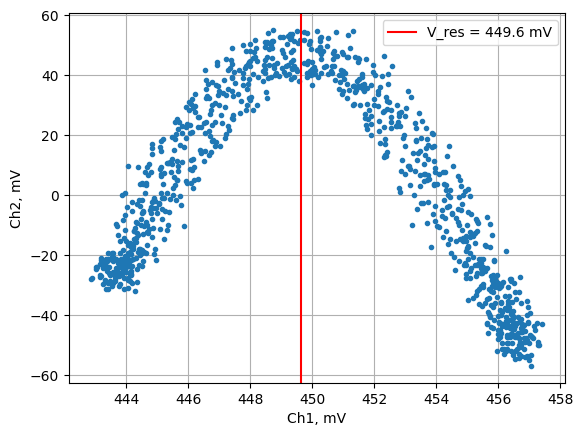

In [ ]:
filename = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/ESR/V_res/set2_1kHz.csv'
t, ch1, ch2 = np.genfromtxt(filename, skip_header=46, delimiter=',',
                    usecols=[1,2,3], unpack=True)
ch1 *=1e3 # mV
ch2 *=1e3 # mV
t *=1e3   # ms
plt.plot(ch1, ch2, '.')
plt.grid()
def parabola(x, a, x0, c):
  return a * (x - x0)**2  + c

popt, pcov = curve_fit(parabola, ch1, ch2)
errs = np.sqrt(np.diag(pcov))
print(popt, errs)
a, x0, c = popt
a_err, x0_err, c_err = errs

v_res =  ufloat(x0, x0_err)
print(v_res)
plt.axvline(v_res.nominal_value, color='red', label=f'V_res = {v_res.n:.1f} mV')
plt.legend()
plt.xlabel('Ch1, mV')
plt.ylabel('Ch2, mV')
plt.xlabel('Ch1, mV')
plt.ylabel('Ch2, mV')

# Resonanse conditions

In [ ]:
# Resonance condition: h*nu = g*mu_B*B_res
# Convert B_res from mV (on resistor R=0.82 Ohm) to Tesla
R_sense = 0.82          # Ohm
k_coil  = 4462          # A/m per A  (geometric factor, to be measured)
mu0     = 4*np.pi*1e-7

I_res = (v_res * 1e-3) / R_sense          # A
B_res_T = mu0 * k_coil * I_res            # Tesla

nu_RF   = 96e6                            # Hz (from oscillator label)
h       = 6.626e-34
g_DPPH  = 2.0036
mu_B    = 9.274e-24

gamma_measured = h * nu_RF / (mu_B * B_res_T) / (h / (2*np.pi*mu_B))  # dimensionless g
print(f"\nI_res   = {I_res:.4f} A")
print(f"B_res   = {B_res_T*1e3:.2f} mT")
print(f"g (measured) = {h*nu_RF/(mu_B*B_res_T):.4f}  (should be ~2 if nu_RF is correct)")



I_res   = 0.5483+/-0.0080 A
B_res   = 3.07+/-0.04 mT
g (measured) = 2.2309+/-0.0326  (should be ~2 if nu_RF is correct)
